# FC Barcelona – Champions League 2018/19  
## Season Overview & Home vs Away Analysis

**Project:** Why FC Barcelona collapsed vs Liverpool (2018/19)  


This notebook covers:
- Context of the 2018/19 European season  
- Season-level performance analysis  
- Home vs Away performance patterns  
- Identification of anomalies (Tottenham away, Liverpool away)


## 1. Context of the 2018/19 Season

This season is not analyzed in isolation.  
It is part of a broader historical and emotional context for FC Barcelona:

- Trauma of the Roma comeback (2017/18)
- Messi becoming captain after Iniesta’s departure  
- Post-World Cup 2018 context  
- High expectations from fans and media  
- Strong domestic dominance in La Liga  
- Public discourse around "bringing the Champions League back to Barcelona"

This section sets the narrative context of the analysis.


## 2. Research Questions

Main questions:

- Was the collapse at Anfield an isolated accident, or the extreme case of a season-long pattern?
- Did FC Barcelona show a structural imbalance between home and away performances in UCL 2018/19?
- Are there specific away matches that already show warning signs?
- Can we identify exceptions (e.g., Tottenham away)?


## 3. Data & Scope

We use match-level public data for FC Barcelona in the 2018/19 Champions League:

- Scores & Fixtures  
- Shooting statistics (for Barcelona and against Barcelona)

Unit of analysis: one match.  
Scope: all Champions League matches played by FC Barcelona in 2018/19.

Limitations:
- No player tracking data  
- No event-level sequences  
- No tactical annotations  
- Public data only


## 4. Notebook Structure

This notebook is structured as follows:

1. Data loading & basic checks  
2. Season overview (results & performance)  
3. Home vs Away analysis  
4. Identification of anomalies (Tottenham away)  
5. Transition toward Liverpool case study


## 5. Data Loading

In the next section, we load the cleaned CSV files containing:

- Match fixtures and results  
- Shooting statistics for FC Barcelona  
- Shooting statistics against FC Barcelona

We start with simple checks to understand the structure of the data.


In [85]:
import pandas as pd

fixtures = pd.read_csv("../data/barca_ucl_2018_19_fixtures.csv")
shoot_for = pd.read_csv("../data/barca_ucl_2018_19_shooting_for.csv")
shoot_against = pd.read_csv("../data/barca_ucl_2018_19_shooting_against.csv")

fixtures.head()


,date,round,venue,result,goals_for,goals_against,opponent,possession
0,2018-09-18,Group stage,Home,W,4,0,PSV,75
1,2018-10-03,Group stage,Away,W,4,2,Tottenham,61
2,2018-10-24,Group stage,Home,W,2,0,Inter,67
3,2018-11-06,Group stage,Away,D,1,1,Inter,65
4,2018-11-28,Group stage,Away,W,2,1,PSV,65


## 6. First Exploration of the Data

We begin by inspecting:
- column names  
- basic descriptive statistics  
- consistency of dates across tables

The goal is to ensure data quality before any analysis.


In [86]:
# Quick look at the datasets
print("Fixtures shape:", fixtures.shape)
print("Shooting (for) shape:", shoot_for.shape)
print("Shooting (against) shape:", shoot_against.shape)

display(fixtures.head(3))
display(shoot_for.head(3))
display(shoot_against.head(3))


Fixtures shape: (12, 8)
Shooting (for) shape: (12, 6)
Shooting (against) shape: (12, 6)


,date,round,venue,result,goals_for,goals_against,opponent,possession
0,2018-09-18,Group stage,Home,W,4,0,PSV,75
1,2018-10-03,Group stage,Away,W,4,2,Tottenham,61
2,2018-10-24,Group stage,Home,W,2,0,Inter,67


,date,venue,goals,shots,shots_on_target,sot_pct
0,2018-09-18,Home,4,21,9,42.9
1,2018-10-03,Away,4,13,8,61.5
2,2018-10-24,Home,2,21,11,52.4


,date,venue,goals_against,shots_against,shots_on_target_against,sot_pct_against
0,2018-09-18,Away,0,14,1,7.1
1,2018-10-03,Home,2,9,5,55.6
2,2018-10-24,Away,0,9,2,22.2


In [87]:
print("Fixtures columns:")
print(list(fixtures.columns))

print("\nShooting for columns:")
print(list(shoot_for.columns))

print("\nShooting against columns:")
print(list(shoot_against.columns))


Fixtures columns:
['date', 'round', 'venue', 'result', 'goals_for', 'goals_against', 'opponent', 'possession']

Shooting for columns:
['date', 'venue', 'goals', 'shots', 'shots_on_target', 'sot_pct']

Shooting against columns:
['date', 'venue', 'goals_against', 'shots_against', 'shots_on_target_against', 'sot_pct_against']


In [88]:
# Convert date columns to datetime (safer for merges)
fixtures["date"] = pd.to_datetime(fixtures["date"])
shoot_for["date"] = pd.to_datetime(shoot_for["date"])
shoot_against["date"] = pd.to_datetime(shoot_against["date"])

# Check duplicates
print("Duplicate dates in fixtures:", fixtures["date"].duplicated().sum())
print("Duplicate dates in shoot_for:", shoot_for["date"].duplicated().sum())
print("Duplicate dates in shoot_against:", shoot_against["date"].duplicated().sum())

# Check if all dates match across tables
print("Dates in fixtures but missing in shoot_for:",
      fixtures.loc[~fixtures["date"].isin(shoot_for["date"]), "date"].dt.date.tolist())

print("Dates in fixtures but missing in shoot_against:",
      fixtures.loc[~fixtures["date"].isin(shoot_against["date"]), "date"].dt.date.tolist())


Duplicate dates in fixtures: 0
Duplicate dates in shoot_for: 0
Duplicate dates in shoot_against: 0
Dates in fixtures but missing in shoot_for: []
Dates in fixtures but missing in shoot_against: []


In [89]:
# Merge fixtures with shooting (for)
df = fixtures.merge(
    shoot_for.drop(columns=["venue"]),  # venue already in fixtures
    on="date",
    how="left"
)

# Merge with shooting (against)
df = df.merge(
    shoot_against.drop(columns=["venue"]),
    on="date",
    how="left"
)

df.head()


,date,round,venue,result,goals_for,goals_against_x,opponent,possession,goals,shots,shots_on_target,sot_pct,goals_against_y,shots_against,shots_on_target_against,sot_pct_against
0,2018-09-18,Group stage,Home,W,4,0,PSV,75,4,21,9,42.9,0,14,1,7.1
1,2018-10-03,Group stage,Away,W,4,2,Tottenham,61,4,13,8,61.5,2,9,5,55.6
2,2018-10-24,Group stage,Home,W,2,0,Inter,67,2,21,11,52.4,0,9,2,22.2
3,2018-11-06,Group stage,Away,D,1,1,Inter,65,1,26,8,30.8,1,10,2,20.0
4,2018-11-28,Group stage,Away,W,2,1,PSV,65,2,21,8,38.1,1,23,9,39.1


In [90]:
# Keep the correct goals_against from fixtures
df = df.rename(columns={"goals_against_x": "goals_against"})

# Drop duplicate goals_against from shooting_against
df = df.drop(columns=["goals_against_y"])

# Sanity check
df.columns

# Standardize venue values (just in case)
df["venue"] = df["venue"].str.lower()  # home / away

# Create goal difference
df["goal_diff"] = df["goals_for"] - df["goals_against"]

# Create shots difference
df["shots_diff"] = df["shots"] - df["shots_against"]

# Quick check
df[["date", "opponent", "venue", "goals_for", "goals_against", "goal_diff", "shots", "shots_against", "shots_diff"]]


,date,opponent,venue,goals_for,goals_against,goal_diff,shots,shots_against,shots_diff
0,2018-09-18,PSV,home,4,0,4,21,14,7
1,2018-10-03,Tottenham,away,4,2,2,13,9,4
2,2018-10-24,Inter,home,2,0,2,21,9,12
3,2018-11-06,Inter,away,1,1,0,26,10,16
4,2018-11-28,PSV,away,2,1,1,21,23,-2
5,2018-12-11,Tottenham,home,1,1,0,14,17,-3
6,2019-02-19,Lyon,away,0,0,0,25,5,20
7,2019-03-13,Lyon,home,5,1,4,19,11,8
8,2019-04-10,Manchester United,away,1,0,1,6,10,-4
9,2019-04-16,Manchester United,home,3,0,3,13,9,4


In [91]:
home_away_summary = df.groupby("venue").agg(
    matches=("venue", "count"),
    goals_for=("goals_for", "sum"),
    goals_against=("goals_against", "sum"),
    goal_diff=("goal_diff", "sum"),
    shots_for=("shots", "sum"),
    shots_against=("shots_against", "sum"),
    shots_diff=("shots_diff", "sum"),
    possession_avg=("possession", "mean"),
)

home_away_summary

,matches,goals_for,goals_against,goal_diff,shots_for,shots_against,shots_diff,possession_avg
venue,,,,,,,,
away,6,8,8,0,99,71,28,63.0
home,6,18,2,16,100,75,25,60.0


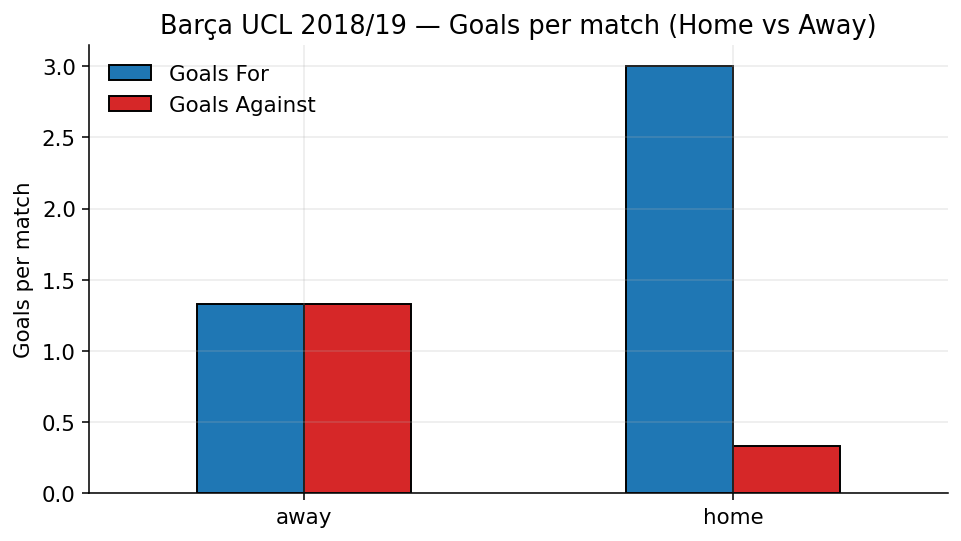

In [92]:
import matplotlib.pyplot as plt

summary_goals = df.groupby("venue").agg(
    matches=("venue","count"),
    goals_for=("goals_for","sum"),
    goals_against=("goals_against","sum"),
)
summary_goals["goals_for_per_match"] = summary_goals["goals_for"] / summary_goals["matches"]
summary_goals["goals_against_per_match"] = summary_goals["goals_against"] / summary_goals["matches"]

ax = summary_goals[["goals_for_per_match","goals_against_per_match"]].plot(
    kind="bar",
    figsize=(7,4),
    color=["#1f77b4", "#d62728"],  # bleu / rouge
    edgecolor="black"
)

plt.title("Barça UCL 2018/19 — Goals per match (Home vs Away)")
plt.xlabel("")
plt.ylabel("Goals per match")
plt.xticks(rotation=0)
plt.legend(["Goals For", "Goals Against"], frameon=False)
plt.tight_layout()
plt.show()


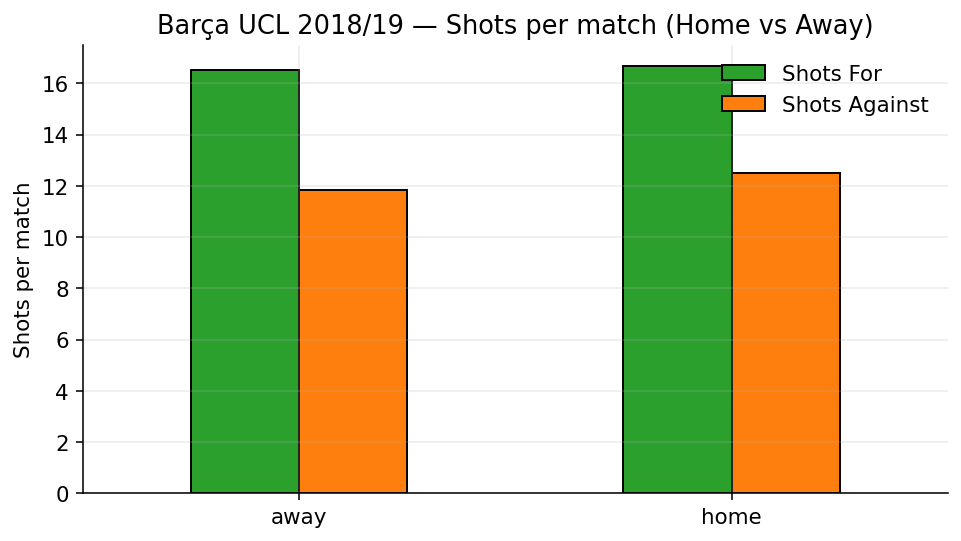

In [93]:
summary_shots = df.groupby("venue").agg(
    matches=("venue","count"),
    shots_for=("shots","sum"),
    shots_against=("shots_against","sum"),
)
summary_shots["shots_for_per_match"] = summary_shots["shots_for"] / summary_shots["matches"]
summary_shots["shots_against_per_match"] = summary_shots["shots_against"] / summary_shots["matches"]

ax = summary_shots[["shots_for_per_match","shots_against_per_match"]].plot(
    kind="bar",
    figsize=(7,4),
    color=["#2ca02c", "#ff7f0e"],  # vert / orange
    edgecolor="black"
)

plt.title("Barça UCL 2018/19 — Shots per match (Home vs Away)")
plt.xlabel("")
plt.ylabel("Shots per match")
plt.xticks(rotation=0)
plt.legend(["Shots For", "Shots Against"], frameon=False)
plt.tight_layout()
plt.show()


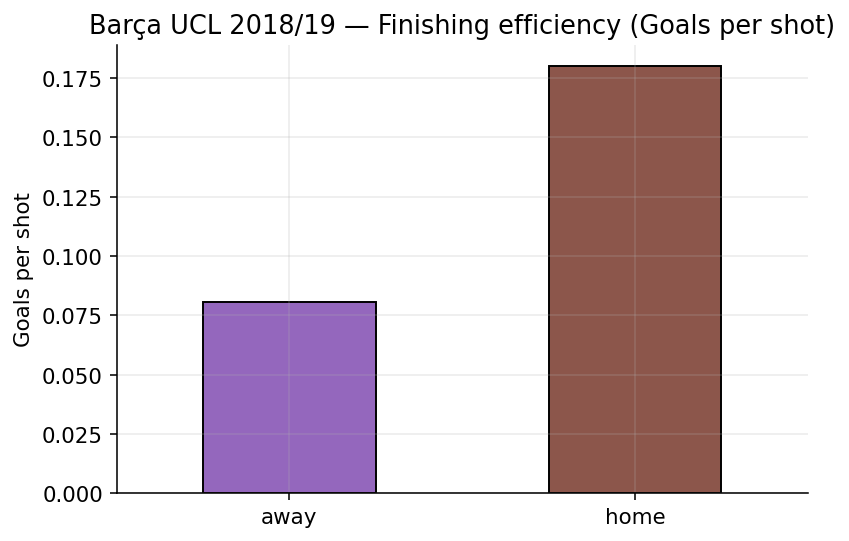

,goals_for,shots,goals_per_shot
venue,,,
away,8,99,0.080808
home,18,100,0.180000


In [94]:
eff = df.groupby("venue").agg(
    goals_for=("goals_for","sum"),
    shots=("shots","sum")
)
eff["goals_per_shot"] = eff["goals_for"] / eff["shots"]
ax = eff["goals_per_shot"].plot(
    kind="bar",
    figsize=(6,4),
    color=["#9467bd", "#8c564b"],  # violet / marron
    edgecolor="black"
)

plt.title("Barça UCL 2018/19 — Finishing efficiency (Goals per shot)")
plt.xlabel("")
plt.ylabel("Goals per shot")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
eff


In [95]:
away_matches = df[df["venue"] == "away"][["date", "opponent", "result", "goals_for", "goals_against", "goal_diff", "shots_diff"]]
away_matches.sort_values("date")


,date,opponent,result,goals_for,goals_against,goal_diff,shots_diff
1,2018-10-03,Tottenham,W,4,2,2,4
3,2018-11-06,Inter,D,1,1,0,16
4,2018-11-28,PSV,W,2,1,1,-2
6,2019-02-19,Lyon,D,0,0,0,20
8,2019-04-10,Manchester United,W,1,0,1,-4
11,2019-05-07,Liverpool,L,0,4,-4,-6



The away matches reveal a recurring pattern:

- Barcelona often dominates possession and shot volume away from home.
- However, this dominance does not consistently translate into goals or safe margins.
- Several away wins show negative or weak shot differentials.
- Tottenham (Away) stands out as a positive exception.
- Liverpool (Away) represents the extreme case where control collapses into a heavy defeat.

This section suggests that the Anfield collapse is not fully isolated, but the most visible failure of a recurring away-game fragility.

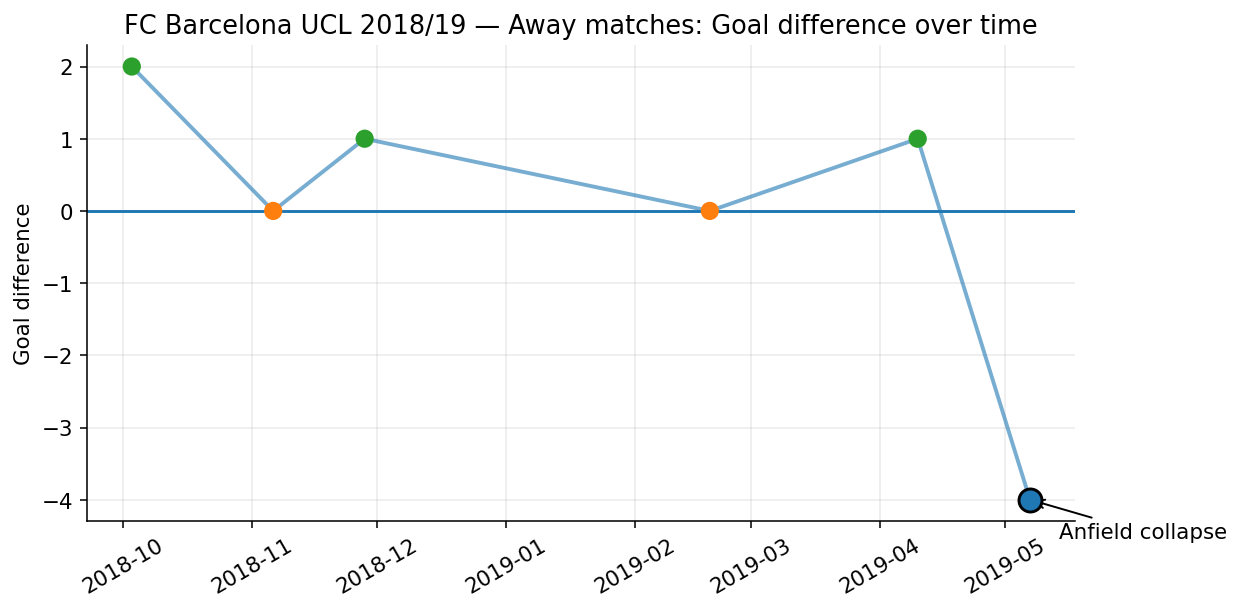

In [96]:
away = df[df["venue"] == "away"].sort_values("date")

plt.figure(figsize=(9,4.5))

# Line
plt.plot(away["date"], away["goal_diff"], linewidth=2, alpha=0.6)

# Points colorés selon le résultat
colors = away["result"].map({"W": "#2ca02c", "D": "#ff7f0e", "L": "#d62728"})
plt.scatter(away["date"], away["goal_diff"], s=70, c=colors, zorder=3)

# Ligne zéro
plt.axhline(0)

# Mettre Liverpool en évidence
liverpool_away = away[away["opponent"] == "Liverpool"]
plt.scatter(liverpool_away["date"], liverpool_away["goal_diff"], 
            s=140, edgecolor="black", linewidth=1.5, zorder=4)
plt.annotate("Anfield collapse",
             (liverpool_away["date"].iloc[0], liverpool_away["goal_diff"].iloc[0]),
             xytext=(15, -20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", lw=1))

# Style propre
plt.title("FC Barcelona UCL 2018/19 — Away matches: Goal difference over time")
plt.xlabel("")
plt.ylabel("Goal difference")
plt.xticks(rotation=30)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Match Profile — Tottenham (Away)

This section builds a *team-level match profile* for the away game against Tottenham (3 Oct 2018).
The goal is to understand **why this match is a positive away reference case**.

We compare Barcelona vs Tottenham on:
- Possession and passing accuracy (control)
- Shots and shots on target (chance creation + execution)
- Defensive actions (tackles, interceptions)
- Style indicators (crosses, long balls, aerials won, clearances)
- Game flow proxies (offsides, throw-ins, goal kicks)

This match profile will later be compared with the Liverpool (Away) match to highlight why Anfield was a high-risk scenario.


In [97]:
import pandas as pd
import matplotlib.pyplot as plt

team_stats = pd.read_csv("../data/team_match_stats_2018_10_03_tottenham.csv")
team_stats


,date,opponent,venue,round,team,poss_pct,pass_acc_pct,shots,shots_on_target,fouls,corners,crosses,tackles,interceptions,long_balls,aerials_won,clearances,offsides,throw_ins,goal_kicks
0,2018-10-03,Tottenham,Away,Group stage,Barcelona,61,89,13,8,9,1,2,21,11,58,6,11,3,24,6
1,2018-10-03,Tottenham,Away,Group stage,Tottenham,39,87,9,5,18,3,14,19,9,46,8,7,7,11,6


In [98]:
# Make sure numeric columns are numeric
numeric_cols = [
    "poss_pct","pass_acc_pct","shots","shots_on_target","fouls","corners","crosses",
    "tackles","interceptions","long_balls","aerials_won","clearances",
    "offsides","throw_ins","goal_kicks"
]
for c in numeric_cols:
    team_stats[c] = pd.to_numeric(team_stats[c], errors="coerce")

# Set index for clean viewing
comparison_table = team_stats.set_index("team")[numeric_cols]
comparison_table


,poss_pct,pass_acc_pct,shots,shots_on_target,fouls,corners,crosses,tackles,interceptions,long_balls,aerials_won,clearances,offsides,throw_ins,goal_kicks
team,,,,,,,,,,,,,,,
Barcelona,61,89,13,8,9,1,2,21,11,58,6,11,3,24,6
Tottenham,39,87,9,5,18,3,14,19,9,46,8,7,7,11,6


In [99]:
derived = team_stats.copy()

derived["shot_accuracy"] = derived["shots_on_target"] / derived["shots"]
derived["def_actions"] = derived["tackles"] + derived["interceptions"]
derived["directness_proxy"] = derived["long_balls"] + derived["crosses"]
derived["pressure_proxy"] = derived["clearances"] + derived["goal_kicks"]  # rough proxy

derived_metrics = derived.set_index("team")[["shot_accuracy","def_actions","directness_proxy","pressure_proxy"]]
derived_metrics


,shot_accuracy,def_actions,directness_proxy,pressure_proxy
team,,,,
Barcelona,0.615385,32,60,17
Tottenham,0.555556,28,60,13


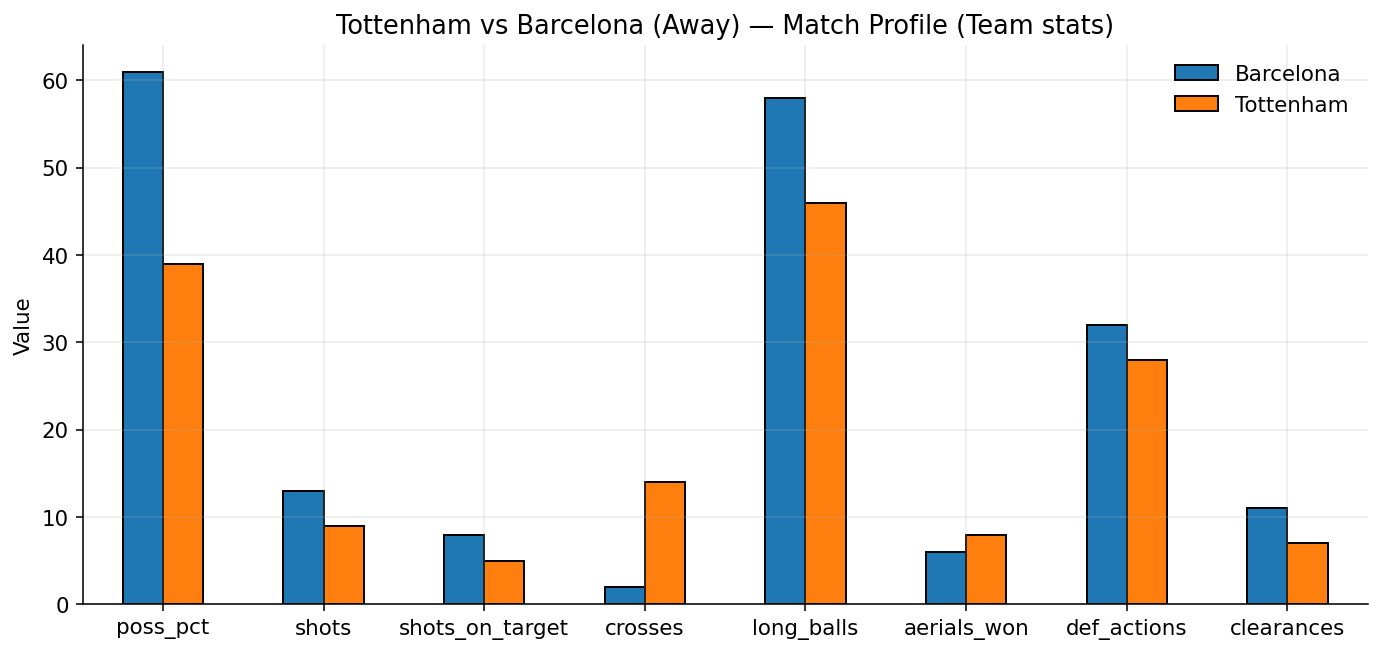

In [100]:
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

metrics = ["poss_pct", "shots", "shots_on_target", "crosses", "long_balls", "aerials_won", "def_actions", "clearances"]
plot_df = derived.set_index("team")[metrics].T

ax = plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("Tottenham vs Barcelona (Away) — Match Profile (Team stats)")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


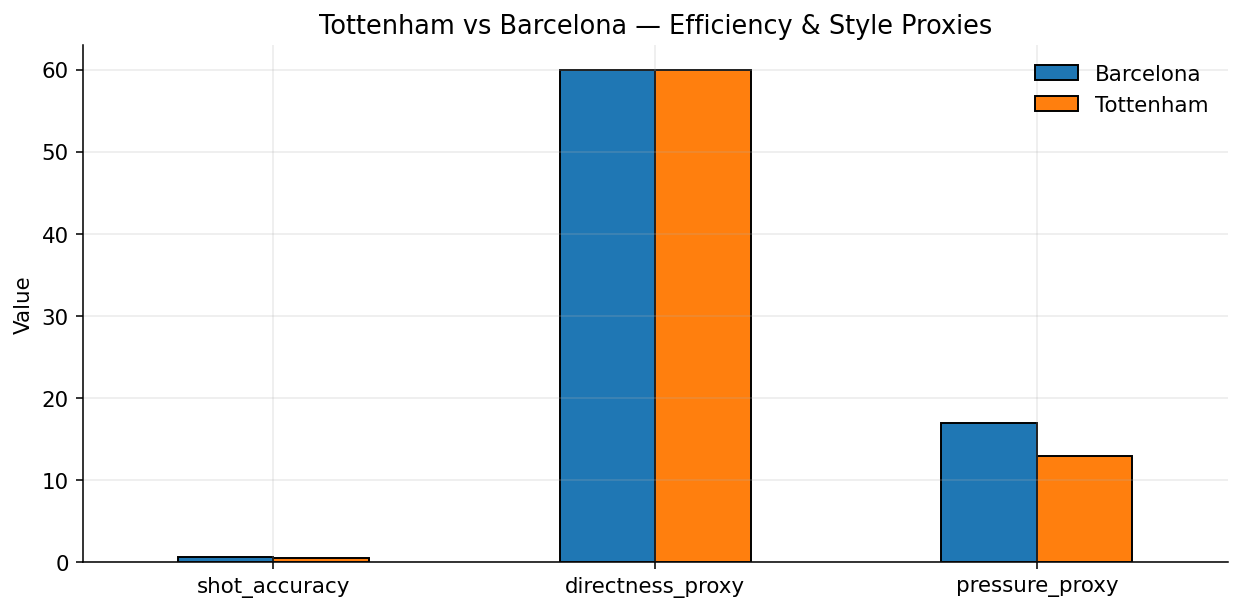

In [101]:
plot2 = derived.set_index("team")[["shot_accuracy","directness_proxy","pressure_proxy"]].T

ax = plot2.plot(kind="bar", figsize=(9,4.5), edgecolor="black")
plt.title("Tottenham vs Barcelona — Efficiency & Style Proxies")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [102]:
barca = comparison_table.loc["Barcelona"]
spurs = comparison_table.loc["Tottenham"]

diff = (barca - spurs).to_frame(name="Barcelona_minus_Tottenham")
diff.sort_values("Barcelona_minus_Tottenham", ascending=False)


,Barcelona_minus_Tottenham
poss_pct,22
throw_ins,13
long_balls,12
shots,4
clearances,4
shots_on_target,3
pass_acc_pct,2
tackles,2
interceptions,2
goal_kicks,0


### Interpretation (Tottenham Away)

Barcelona controlled the match through possession (61%) and strong passing accuracy (89%).
Tottenham relied more on crossing and aerial play (14 crosses, 8 aerials won), suggesting a more direct approach.

Despite being an away game, Barcelona showed:
- higher shot accuracy (8/13 on target)
- high defensive activity (tackles + interceptions)
- enough control to limit Tottenham’s ability to convert chances

This match stands out as a positive away reference case and will be contrasted with the Liverpool (Away) collapse.


## 8. Player-Level Performance — Tottenham (Away)

This section analyzes individual performances for FC Barcelona in the away match against Tottenham.
The goal is to identify:
- key contributors to the away win,
- underperforming players,
- efficiency vs volume (shots vs goals),
- early warning signs (e.g., striker inefficiency away from home).

Player metrics are normalized per 90 minutes to allow fair comparisons.


In [103]:
import pandas as pd

players = pd.read_csv("../data/player_match_stats_2018_10_03_tottenham.csv")
players


,date,opponent,venue,round,player,position,minutes,goals,assists,shots,shots_on_target,offsides,crosses,tackles_won,interceptions,fouls_committed,fouls_drawn
0,2018-10-03,Tottenham,Away,Group stage,Philippe Coutinho,FW,82,1,1,2,2,2,0,0,1,1,2
1,2018-10-03,Tottenham,Away,Group stage,Rafinha,MF,8,0,0,0,0,0,0,0,0,0,0
2,2018-10-03,Tottenham,Away,Group stage,Luis Suárez,FW,90,0,0,3,1,0,0,0,0,0,3
3,2018-10-03,Tottenham,Away,Group stage,Lionel Messi,FW,90,2,0,6,4,0,1,2,1,1,3
4,2018-10-03,Tottenham,Away,Group stage,Ivan Rakitić,CM,90,1,0,1,1,0,0,0,2,0,0
5,2018-10-03,Tottenham,Away,Group stage,Sergio Busquets,CM,89,0,0,0,0,0,0,3,0,2,1
6,2018-10-03,Tottenham,Away,Group stage,Thomas Vermaelen,DF,1,0,0,0,0,0,0,0,0,0,1
7,2018-10-03,Tottenham,Away,Group stage,Arthur Melo,CM,86,0,0,0,0,0,0,3,0,1,3
8,2018-10-03,Tottenham,Away,Group stage,Arturo Vidal,MF,4,0,0,0,0,0,0,0,0,1,0
9,2018-10-03,Tottenham,Away,Group stage,Jordi Alba,LB,90,0,3,0,0,1,0,1,3,2,0


In [104]:
# Avoid division by zero
players["per90"] = players["minutes"] / 90

players["shots_per_90"] = players["shots"] / players["per90"]
players["goals_per_90"] = players["goals"] / players["per90"]
players["sot_per_90"] = players["shots_on_target"] / players["per90"]

players["shot_accuracy"] = players["shots_on_target"] / players["shots"].replace(0, pd.NA)
players["goals_per_shot"] = players["goals"] / players["shots"].replace(0, pd.NA)

players[["player","minutes","goals","assists","shots","shots_on_target","shots_per_90","goals_per_90","shot_accuracy","goals_per_shot"]].sort_values("shots", ascending=False)


,player,minutes,goals,assists,shots,shots_on_target,shots_per_90,goals_per_90,shot_accuracy,goals_per_shot
3,Lionel Messi,90,2,0,6,4,6.000000,2.000000,0.666667,0.333333
2,Luis Suárez,90,0,0,3,1,3.000000,0.000000,0.333333,0.0
0,Philippe Coutinho,82,1,1,2,2,2.195122,1.097561,1.0,0.5
4,Ivan Rakitić,90,1,0,1,1,1.000000,1.000000,1.0,1.0
10,Clément Lenglet,90,0,0,1,0,1.000000,0.000000,0.0,0.0
1,Rafinha,8,0,0,0,0,0.000000,0.000000,<NA>,<NA>
5,Sergio Busquets,89,0,0,0,0,0.000000,0.000000,<NA>,<NA>
6,Thomas Vermaelen,1,0,0,0,0,0.000000,0.000000,<NA>,<NA>
7,Arthur Melo,86,0,0,0,0,0.000000,0.000000,<NA>,<NA>
8,Arturo Vidal,4,0,0,0,0,0.000000,0.000000,<NA>,<NA>


In [105]:
players["impact_score"] = (
    3 * players["goals"] +
    2 * players["assists"] +
    0.3 * players["shots_on_target"] +
    0.1 * (players["tackles_won"] + players["interceptions"])
)

players.sort_values("impact_score", ascending=False)[
    ["player","position","minutes","goals","assists","shots_on_target","tackles_won","interceptions","impact_score"]
]


,player,position,minutes,goals,assists,shots_on_target,tackles_won,interceptions,impact_score
3,Lionel Messi,FW,90,2,0,4,2,1,7.5
9,Jordi Alba,LB,90,0,3,0,1,3,6.4
0,Philippe Coutinho,FW,82,1,1,2,0,1,5.7
4,Ivan Rakitić,CM,90,1,0,1,0,2,3.5
11,Gerard Piqué,CB,90,0,0,0,1,3,0.4
5,Sergio Busquets,CM,89,0,0,0,3,0,0.3
7,Arthur Melo,CM,86,0,0,0,3,0,0.3
12,Nélson Semedo,RB,90,0,0,0,2,1,0.3
2,Luis Suárez,FW,90,0,0,1,0,0,0.3
10,Clément Lenglet,CB,90,0,0,0,2,0,0.2


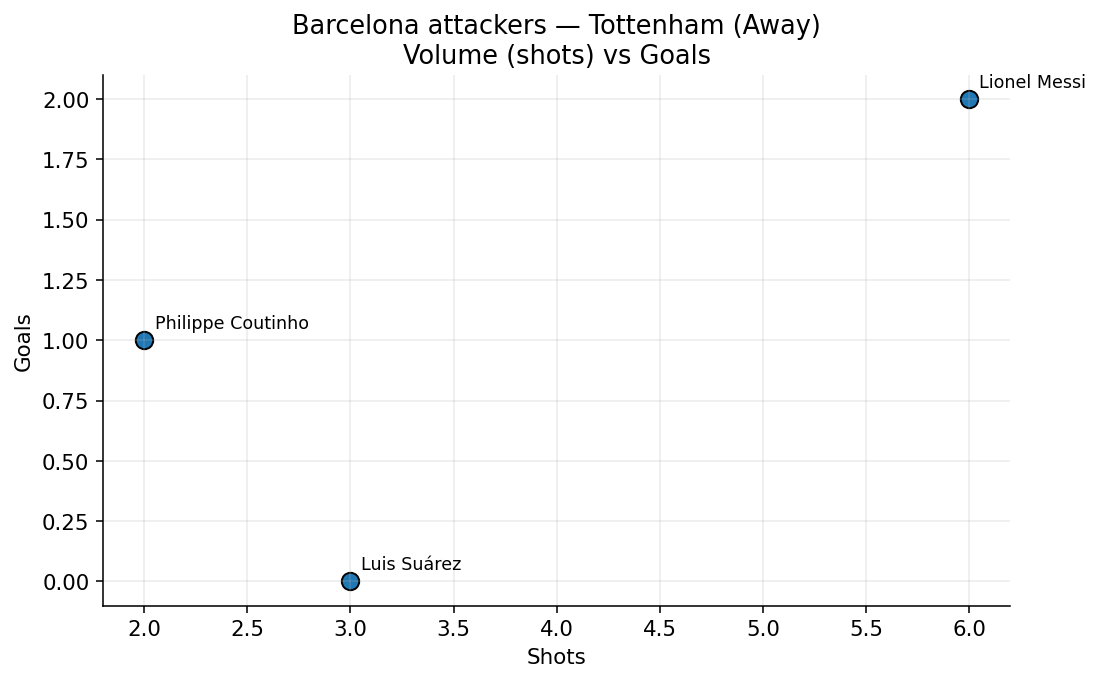

In [106]:
import matplotlib.pyplot as plt

attackers = players[players["position"].isin(["FW","MF"]) & (players["shots"] > 0)]

plt.figure(figsize=(8,5))
plt.scatter(attackers["shots"], attackers["goals"], s=80, edgecolor="black")
for _, r in attackers.iterrows():
    plt.text(r["shots"]+0.05, r["goals"]+0.05, r["player"], fontsize=9)

plt.title("Barcelona attackers — Tottenham (Away)\nVolume (shots) vs Goals")
plt.xlabel("Shots")
plt.ylabel("Goals")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [107]:
players[players["player"].isin(["Lionel Messi","Luis Suárez"])][
    ["player","minutes","shots","shots_on_target","goals","goals_per_shot","shot_accuracy"]
]


,player,minutes,shots,shots_on_target,goals,goals_per_shot,shot_accuracy
2,Luis Suárez,90,3,1,0,0.0,0.333333
3,Lionel Messi,90,6,4,2,0.333333,0.666667


Messi emerges as the primary offensive driver in the away win at Tottenham, combining high shot volume with strong finishing efficiency.
In contrast, Suárez registers multiple shots without scoring, reinforcing the hypothesis of declining away-game finishing efficiency for the central striker.
This contrast between volume and effectiveness will be further examined in the Liverpool (Away) case.

## 9. Match Profile — Inter (Away)

This section analyzes the away match against Internazionale (6 Nov 2018).
The goal is to understand why Barcelona dominated the match statistically
but failed to secure a win (1–1).

We focus on:
- Team-level control vs outcome (possession, shots, shot accuracy)
- Opponent defensive intensity and match context
- Individual Barcelona performances
- Signs of offensive inefficiency away from home


In [108]:
team_stats_inter = pd.read_csv("../data/team_match_stats_2018_11_06_inter.csv")
team_stats_inter


,date,opponent,venue,round,team,poss_pct,pass_acc_pct,shots,shots_on_target,fouls,corners,crosses,tackles,interceptions,long_balls,aerials_won,clearances,offsides,throw_ins,goal_kicks
0,2018-11-06,Inter,Away,Group stage,Barcelona,65,90,26,8,9,10,16,8,10,53,10,16,0,17,6
1,2018-11-06,Inter,Away,Group stage,Inter,35,83,10,2,11,3,25,22,15,49,14,25,2,12,12


In [109]:
# Derived metrics
team_stats_inter["shot_accuracy"] = team_stats_inter["shots_on_target"] / team_stats_inter["shots"]
team_stats_inter["def_actions"] = team_stats_inter["tackles"] + team_stats_inter["interceptions"]
team_stats_inter["directness_proxy"] = team_stats_inter["long_balls"] + team_stats_inter["crosses"]

team_stats_inter.set_index("team")[["poss_pct","shots","shots_on_target","shot_accuracy","def_actions","directness_proxy","aerials_won","clearances"]]


,poss_pct,shots,shots_on_target,shot_accuracy,def_actions,directness_proxy,aerials_won,clearances
team,,,,,,,,
Barcelona,65,26,8,0.307692,18,69,10,16
Inter,35,10,2,0.200000,37,74,14,25


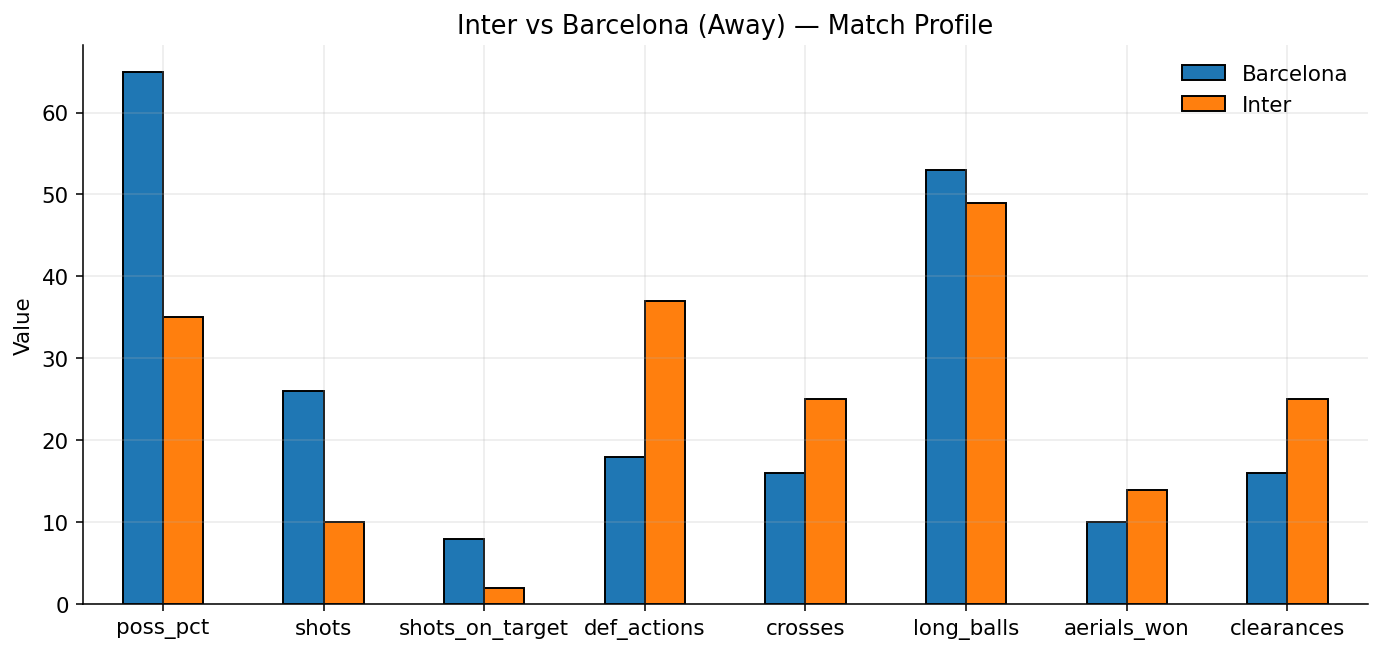

In [110]:
# Plot team profile
metrics = ["poss_pct","shots","shots_on_target","def_actions","crosses","long_balls","aerials_won","clearances"]
plot_df = team_stats_inter.set_index("team")[metrics].T

plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("Inter vs Barcelona (Away) — Match Profile")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [111]:
players_inter = pd.read_csv("../data/player_match_stats_2018_11_06_inter.csv")
players_inter


,date,opponent,venue,round,player,position,minutes,goals,assists,shots,shots_on_target,offsides,crosses,tackles_won,interceptions,fouls_committed,fouls_drawn
0,2018-11-06,Inter,Away,Group stage,Philippe Coutinho,FW,90,0,1,8,3,0,5,1,1,0,4
1,2018-11-06,Inter,Away,Group stage,Luis Suárez,FW,90,0,0,9,1,0,0,1,0,1,0
2,2018-11-06,Inter,Away,Group stage,Ousmane Dembélé,FW,80,0,0,3,2,0,6,1,0,0,1
3,2018-11-06,Inter,Away,Group stage,Malcom,FW,10,1,0,1,1,0,1,0,0,0,2
4,2018-11-06,Inter,Away,Group stage,Arthur Melo,CM,73,0,0,0,0,0,1,1,1,1,2
5,2018-11-06,Inter,Away,Group stage,Arturo Vidal,MF,17,0,0,0,0,0,0,0,1,0,0
6,2018-11-06,Inter,Away,Group stage,Sergio Busquets,CM,90,0,0,0,0,0,0,1,2,1,0
7,2018-11-06,Inter,Away,Group stage,Ivan Rakitić,CM,90,0,0,4,1,0,1,1,2,2,1
8,2018-11-06,Inter,Away,Group stage,Jordi Alba,LB,90,0,0,0,0,0,2,1,1,2,0
9,2018-11-06,Inter,Away,Group stage,Clément Lenglet,CB,90,0,0,1,0,0,0,1,1,1,0


In [112]:
# Per 90 + efficiency
players_inter["per90"] = players_inter["minutes"] / 90
players_inter["shots_per_90"] = players_inter["shots"] / players_inter["per90"]
players_inter["goals_per_90"] = players_inter["goals"] / players_inter["per90"]
players_inter["shot_accuracy"] = players_inter["shots_on_target"] / players_inter["shots"].replace(0, pd.NA)
players_inter["goals_per_shot"] = players_inter["goals"] / players_inter["shots"].replace(0, pd.NA)

players_inter.sort_values("shots", ascending=False)[
    ["player","minutes","shots","shots_on_target","goals","shot_accuracy","goals_per_shot"]
]


,player,minutes,shots,shots_on_target,goals,shot_accuracy,goals_per_shot
1,Luis Suárez,90,9,1,0,0.111111,0.0
0,Philippe Coutinho,90,8,3,0,0.375,0.0
7,Ivan Rakitić,90,4,1,0,0.25,0.0
2,Ousmane Dembélé,80,3,2,0,0.666667,0.0
3,Malcom,10,1,1,1,1.0,1.0
9,Clément Lenglet,90,1,0,0,0.0,0.0
4,Arthur Melo,73,0,0,0,<NA>,<NA>
5,Arturo Vidal,17,0,0,0,<NA>,<NA>
6,Sergio Busquets,90,0,0,0,<NA>,<NA>
8,Jordi Alba,90,0,0,0,<NA>,<NA>


Against Inter, Barcelona produced a dominant away performance in terms of process (65% possession, 26 shots), yet failed to convert this control into a decisive scoreline.
The shot differential (+16) contrasts sharply with the final result (1–1), highlighting a recurring pattern of away-game inefficiency.
The forward line generated high shot volume (notably Suárez with 9 shots) but with low finishing efficiency.
This match reinforces the hypothesis that Barcelona’s away vulnerability is driven more by conversion issues than by lack of territorial control.

## 10. Match Profile — PSV (Away)

This section analyzes the away match against PSV Eindhoven (28 Nov 2018).
Although Barcelona won (2–1), this match raises questions about defensive stability and shot concession away from home.

We focus on:
- Team-level dominance vs defensive vulnerability  
- Player-level efficiency  
- Warning signs in away defensive transitions


In [113]:
team_stats_psv = pd.read_csv("../data/team_match_stats_2018_11_28_psv.csv")

team_stats_psv["shot_accuracy"] = team_stats_psv["shots_on_target"] / team_stats_psv["shots"]
team_stats_psv["def_actions"] = team_stats_psv["tackles"] + team_stats_psv["interceptions"]

team_stats_psv.set_index("team")[["poss_pct","shots","shots_on_target","shot_accuracy","def_actions","crosses","long_balls","aerials_won","clearances"]]


,poss_pct,shots,shots_on_target,shot_accuracy,def_actions,crosses,long_balls,aerials_won,clearances
team,,,,,,,,,
Barcelona,65,21,8,0.380952,32,8,56,18,15
PSV,35,23,9,0.391304,26,15,48,21,23


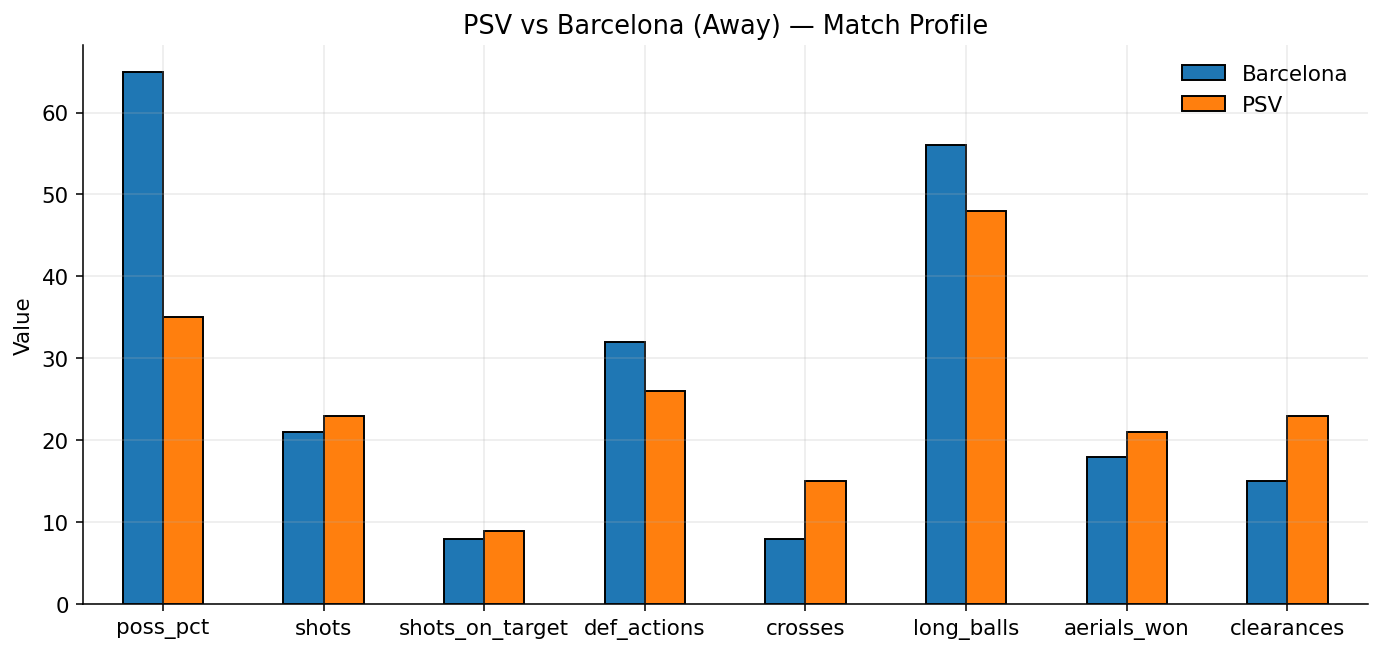

In [114]:
# Plot
metrics = ["poss_pct","shots","shots_on_target","def_actions","crosses","long_balls","aerials_won","clearances"]
plot_df = team_stats_psv.set_index("team")[metrics].T

plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("PSV vs Barcelona (Away) — Match Profile")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [115]:
players_psv = pd.read_csv("../data/player_match_stats_2018_11_28_psv.csv")

players_psv["per90"] = players_psv["minutes"] / 90
players_psv["shots_per_90"] = players_psv["shots"] / players_psv["per90"]
players_psv["goals_per_90"] = players_psv["goals"] / players_psv["per90"]
players_psv["shot_accuracy"] = players_psv["shots_on_target"] / players_psv["shots"].replace(0, pd.NA)

players_psv.sort_values("shots", ascending=False)[
    ["player","minutes","shots","shots_on_target","goals","shot_accuracy"]
]


,player,minutes,shots,shots_on_target,goals,shot_accuracy
2,Lionel Messi,90,6,4,1,0.666667
3,Ousmane Dembélé,79,4,1,0,0.25
5,Arturo Vidal,90,4,2,0,0.5
0,Philippe Coutinho,69,2,0,0,0.0
1,Malcom,21,2,0,0,0.0
7,Ivan Rakitić,90,1,0,0,0.0
8,Jordi Alba,90,1,0,0,0.0
10,Gerard Piqué,90,1,1,1,1.0
4,Denis Suárez,11,0,0,0,<NA>
6,Sergio Busquets,90,0,0,0,<NA>



Despite winning 2–1 away at PSV, Barcelona conceded a high volume of shots (23) and shots on target (9), indicating defensive vulnerability in away transitions.
This match resembles the Manchester United (Away) case, where the outcome was positive but the process was unstable.
The PSV away fixture reinforces the hypothesis that Barcelona’s away performances are structurally fragile even in matches they win.

## 11. Match Profile — Lyon (Away)

This section analyzes the away match against Olympique Lyonnais (19 Feb 2019).
Despite strong territorial control and shot volume, Barcelona failed to score (0–0).

This match represents a key example of *sterile domination* away from home and contrasts sharply with the 5–1 home win in the second leg.


In [116]:
team_stats_lyon = pd.read_csv("../data/team_match_stats_2019_02_19_lyon.csv")

team_stats_lyon["shot_accuracy"] = team_stats_lyon["shots_on_target"] / team_stats_lyon["shots"]
team_stats_lyon["def_actions"] = team_stats_lyon["tackles"] + team_stats_lyon["interceptions"]

team_stats_lyon.set_index("team")[["poss_pct","shots","shots_on_target","shot_accuracy","def_actions","crosses","long_balls","aerials_won","clearances"]]


,poss_pct,shots,shots_on_target,shot_accuracy,def_actions,crosses,long_balls,aerials_won,clearances
team,,,,,,,,,
Barcelona,63,25,5,0.2,36,15,47,8,7
Lyon,37,5,2,0.4,29,11,44,11,29


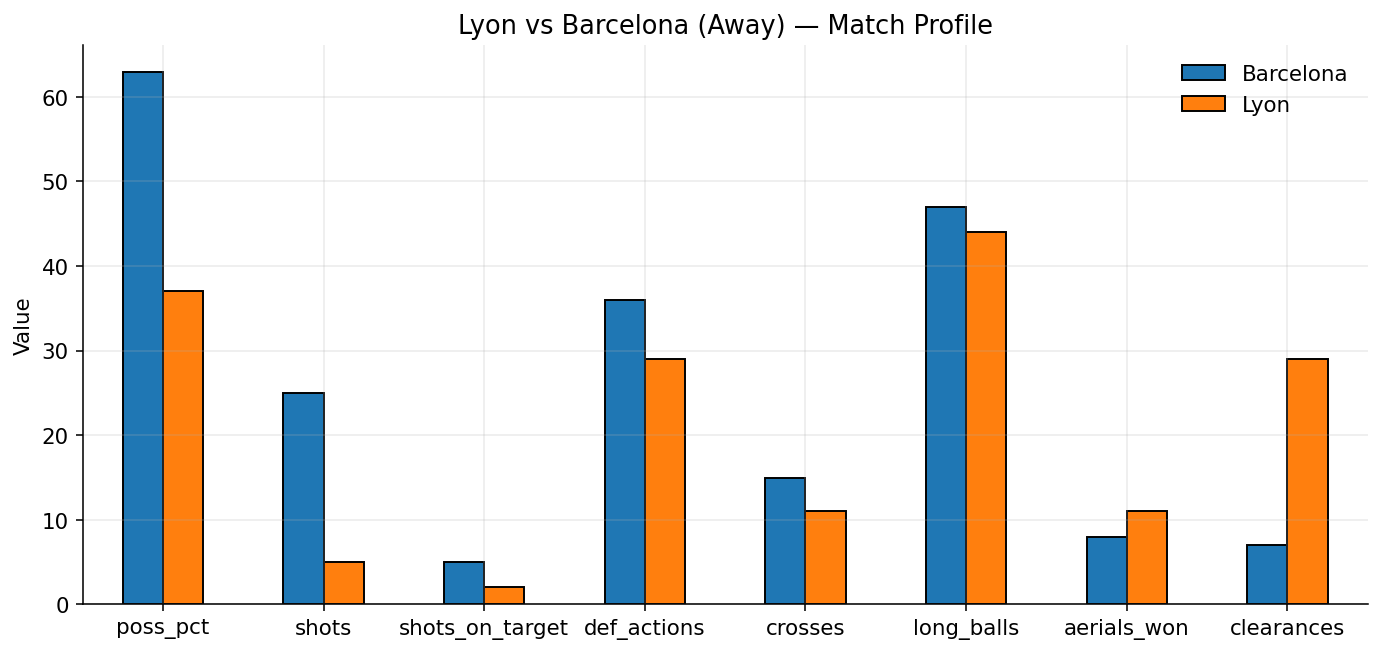

In [117]:
# Plot
metrics = ["poss_pct","shots","shots_on_target","def_actions","crosses","long_balls","aerials_won","clearances"]
plot_df = team_stats_lyon.set_index("team")[metrics].T

plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("Lyon vs Barcelona (Away) — Match Profile")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [118]:
players_lyon = pd.read_csv("../data/player_match_stats_2019_02_19_lyon.csv")

players_lyon["per90"] = players_lyon["minutes"] / 90
players_lyon["shots_per_90"] = players_lyon["shots"] / players_lyon["per90"]
players_lyon["goals_per_90"] = players_lyon["goals"] / players_lyon["per90"]
players_lyon["shot_accuracy"] = players_lyon["shots_on_target"] / players_lyon["shots"].replace(0, pd.NA)

players_lyon.sort_values("shots", ascending=False)[
    ["player","minutes","shots","shots_on_target","goals","shot_accuracy"]
]


,player,minutes,shots,shots_on_target,goals,shot_accuracy
3,Lionel Messi,90,9,1,0,0.111111
0,Ousmane Dembélé,66,4,1,0,0.25
2,Luis Suárez,90,4,1,0,0.25
4,Ivan Rakitić,90,3,0,0,0.0
5,Sergio Busquets,90,2,1,0,0.5
1,Philippe Coutinho,24,1,1,0,1.0
8,Jordi Alba,90,1,0,0,0.0
9,Clément Lenglet,90,1,0,0,0.0
6,Sergi Roberto,80,0,0,0,<NA>
7,Arturo Vidal,10,0,0,0,<NA>


The away match against Lyon illustrates a pattern of sterile domination: Barcelona controlled possession (63%) and generated high shot volume (25 shots), yet produced low shot accuracy (20%) and failed to score.
The forward line, including Messi and Suárez, generated volume without efficiency, reinforcing concerns about away-game finishing.
The stark contrast with the 5–1 home win in the second leg highlights the home–away asymmetry in Barcelona’s Champions League performance.

## 12. Match Profile — Manchester United (Away)

This away match ended 1–0 for Barcelona, but the goal was an **own goal**.
This is a key example where the *result* was positive while the *attacking output* (Barcelona-scored goals) was limited.

We analyze:
- Team-level control vs chance creation  
- Low shot volume despite high possession  
- Player-level attacking contribution  
- Why this match can be considered a “fragile win” away from home  

This match will later be compared with Liverpool (Away) to understand how small margins can collapse.


In [119]:
team_stats_mu = pd.read_csv("../data/team_match_stats_2019_04_10_manutd.csv")

team_stats_mu["shot_accuracy"] = team_stats_mu["shots_on_target"] / team_stats_mu["shots"]
team_stats_mu["def_actions"] = team_stats_mu["tackles"] + team_stats_mu["interceptions"]

team_stats_mu.set_index("team")[["poss_pct","shots","shots_on_target","shot_accuracy","def_actions","crosses","long_balls","aerials_won","clearances"]]


,poss_pct,shots,shots_on_target,shot_accuracy,def_actions,crosses,long_balls,aerials_won,clearances
team,,,,,,,,,
Barcelona,67,6,3,0.5,14,6,57,7,21
Manchester United,34,10,0,0.0,24,18,42,11,13


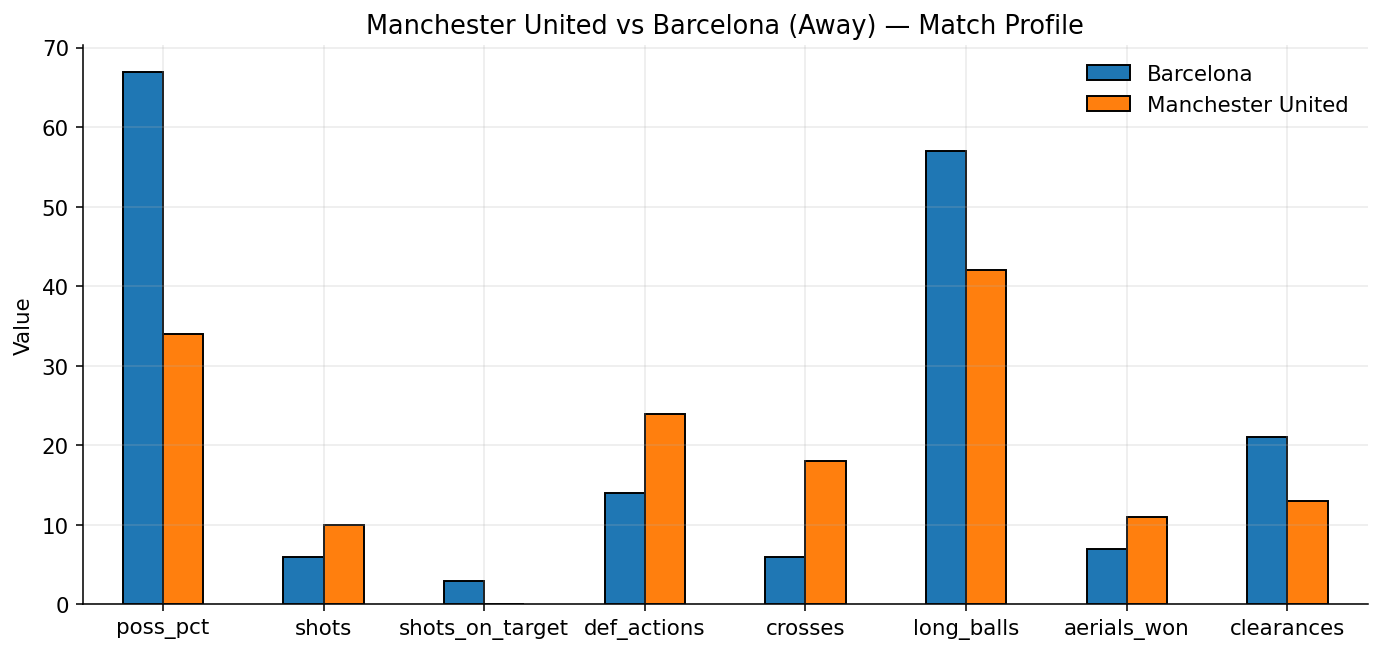

In [120]:
metrics = ["poss_pct","shots","shots_on_target","def_actions","crosses","long_balls","aerials_won","clearances"]
plot_df = team_stats_mu.set_index("team")[metrics].T

plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("Manchester United vs Barcelona (Away) — Match Profile")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [121]:
players_mu = pd.read_csv("../data/player_match_stats_2019_04_10_manutd.csv")

players_mu["per90"] = players_mu["minutes"] / 90
players_mu["shots_per_90"] = players_mu["shots"] / players_mu["per90"]
players_mu["shot_accuracy"] = players_mu["shots_on_target"] / players_mu["shots"].replace(0, pd.NA)

players_mu.sort_values("shots", ascending=False)[
    ["player","minutes","shots","shots_on_target","shot_accuracy","fouls_drawn"]
]


,player,minutes,shots,shots_on_target,shot_accuracy,fouls_drawn
2,Luis Suárez,90,3,0,0.0,3
0,Philippe Coutinho,64,1,1,1.0,3
3,Lionel Messi,90,1,1,1.0,2
9,Jordi Alba,90,1,1,1.0,0
1,Arturo Vidal,26,0,0,<NA>,1
4,Ivan Rakitić,90,0,0,<NA>,1
5,Sergio Busquets,89,0,0,<NA>,1
6,Carles Aleñá,1,0,0,<NA>,0
7,Arthur Melo,65,0,0,<NA>,2
8,Sergi Roberto,25,0,0,<NA>,0


Barcelona secured a 1–0 away win at Old Trafford, but the decisive goal was an own goal, not a Barcelona-scored goal.
Despite controlling possession (67%), Barcelona generated low shot volume (6 total shots), suggesting a conservative approach or difficulties creating chances.
The contrast with the 3–0 home win highlights once again the home–away asymmetry in Barcelona’s Champions League performance.

# Away Matches Summary — 2018/19 Champions League (FC Barcelona)


Across the 2018/19 Champions League campaign, FC Barcelona’s away performances reveal a recurring structural fragility that goes beyond individual results. While some away fixtures ended positively in terms of scoreline, the underlying performance indicators show instability in both chance creation and defensive control.

Against Inter (Away), Barcelona dominated possession (65%) and produced a high volume of shots (26), yet only managed a 1–1 draw. This match illustrates a first pattern of dominance without decisive efficiency, where territorial control failed to translate into a clear advantage on the scoreboard.
The away match at PSV (2–1 win) further reinforces this pattern. Despite winning, Barcelona conceded a high volume of shots (23) and shots on target (9), exposing defensive vulnerability in away transitions. This suggests that positive results away from home often masked underlying structural issues.

The Lyon away fixture (0–0) represents the clearest example of sterile domination. Barcelona controlled possession (63%) and generated 25 shots, yet failed to score. This performance highlights the gap between process and outcome: high territorial and shot dominance did not lead to offensive efficiency.
At Old Trafford against Manchester United, Barcelona once again controlled the match territorially (67% possession) but produced only 6 shots in total (compared to 25 against Lyon). This mismatch between control and chance creation illustrates a recurring pattern of limited attacking production away from home. Moreover, the 1–0 away victory resulted from an own goal rather than a Barcelona-scored goal, underlining the fragility of the offensive output despite a positive result.
Taken together, these away performances suggest that Barcelona’s Champions League campaign was characterized by unstable away-game structures. Dominance in possession did not consistently translate into chance quality or finishing efficiency, while positive results were sometimes achieved despite limited attacking production or defensive vulnerability.

In this context, the collapse at Anfield should not be interpreted as an isolated anomaly, but rather as the most extreme manifestation of a season-long pattern of away-game fragility.

## 16. Match Profile — Liverpool (Home, 1st Leg)

This section provides a quantitative deep-dive of the first leg against Liverpool (3–0).
We go beyond raw counts to analyze:
- chance quality vs volume,
- efficiency vs process,
- defensive pressure absorption,
- style-of-play indicators,
- player-level contribution and finishing efficiency.

This match serves as the quantitative baseline to explain the collapse at Anfield.



In [122]:
team_stats_liv_home = pd.read_csv("../data/team_match_stats_2019_05_01_liverpool_home.csv")

team_stats_liv_home["shot_accuracy"] = team_stats_liv_home["shots_on_target"] / team_stats_liv_home["shots"]
team_stats_liv_home["def_actions"] = team_stats_liv_home["tackles"] + team_stats_liv_home["interceptions"]

team_stats_liv_home.set_index("team")[["poss_pct","shots","shots_on_target","shot_accuracy","def_actions","crosses","long_balls","aerials_won","clearances"]]


,poss_pct,shots,shots_on_target,shot_accuracy,def_actions,crosses,long_balls,aerials_won,clearances
team,,,,,,,,,
Barcelona,48,12,5,0.416667,27,3,55,10,32
Liverpool,52,15,5,0.333333,29,18,52,16,8


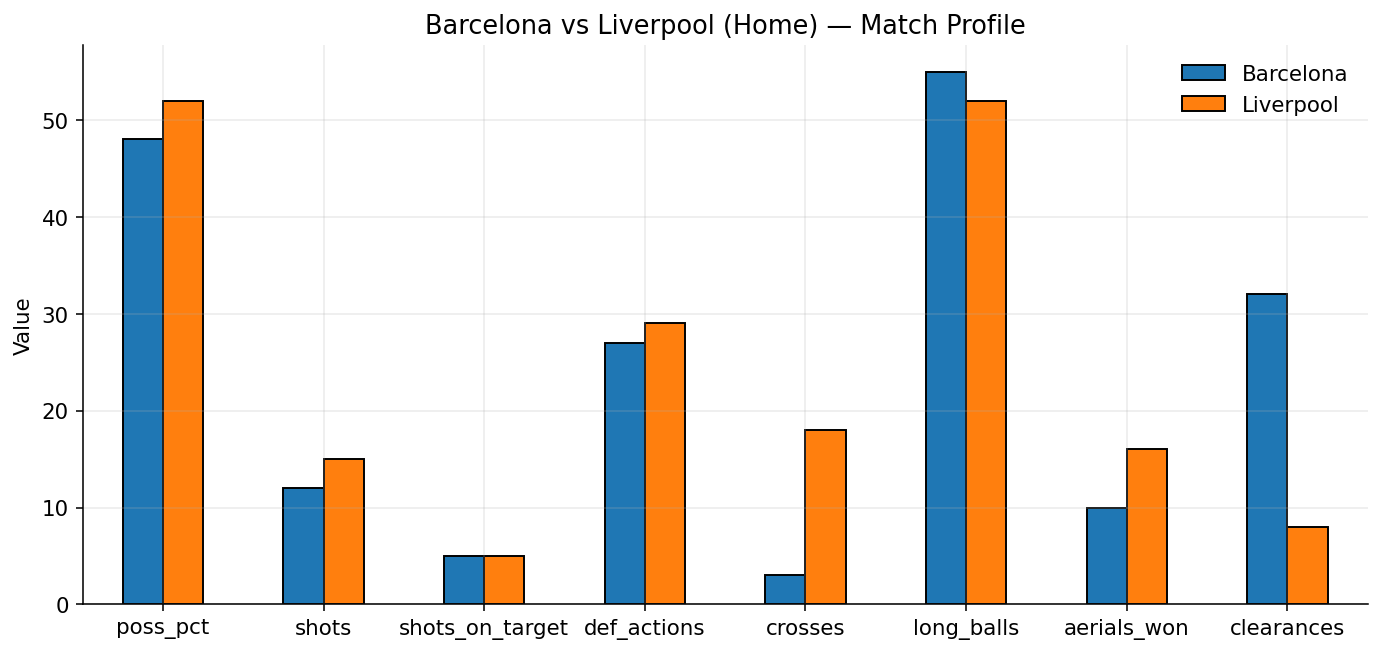

In [123]:
metrics = ["poss_pct","shots","shots_on_target","def_actions","crosses","long_balls","aerials_won","clearances"]
plot_df = team_stats_liv_home.set_index("team")[metrics].T

plot_df.plot(kind="bar", figsize=(10,4.8), edgecolor="black")
plt.title("Barcelona vs Liverpool (Home) — Match Profile")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [124]:
team = team_stats_liv_home.copy()

team["shot_accuracy"] = team["shots_on_target"] / team["shots"]
team["saves_rate"] = team["shots_on_target"] / (team["shots_on_target"] + 1e-6)
team["def_intensity"] = team["tackles"] + team["interceptions"]
team["pressure_absorption"] = team["clearances"] + team["goal_kicks"]
team["direct_play_index"] = team["long_balls"] + team["crosses"]
team["territorial_control_index"] = team["poss_pct"] * team["pass_acc_pct"] / 100

team.set_index("team")[[
    "territorial_control_index",
    "shots",
    "shots_on_target",
    "shot_accuracy",
    "def_intensity",
    "pressure_absorption",
    "direct_play_index",
    "aerials_won"
]]


,territorial_control_index,shots,shots_on_target,shot_accuracy,def_intensity,pressure_absorption,direct_play_index,aerials_won
team,,,,,,,,
Barcelona,40.32,12,5,0.416667,27,38,58,10
Liverpool,43.16,15,5,0.333333,29,14,70,16
